## ⚙️ **Libraries Import**

In [1]:
!pip install protobuf==3.20.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 4.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.0
    Uninstalling protobuf-6.33.0:
      Successfully uninstalled protobuf-6.33.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
onnx 1.18.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
a2a-sdk 0.3.10 requires protobuf>=5.29.5, but you have protobuf 3.20.3 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
tensorflow-me

In [2]:
!pip install timm transformers huggingface_hub xgboost optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 113.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 94.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitl

In [3]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils import class_weight

from sklearn.model_selection import StratifiedKFold

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
from torchvision.models import (
    efficientnet_v2_s, EfficientNet_V2_S_Weights,
    resnet50, ResNet50_Weights
)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# 1. Setup Device & Seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.benchmark = True
    print(f"🌱 Seed set to {seed}")

SEED = 42
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device: {device}")

🌱 Seed set to 42
🚀 Device: cuda


## ⚙️ **Global Config**

In [4]:
class Config:
    # Paths
    # KAGGLE_PATH = "/kaggle/input/an2dl-second-challenge/an2dl/"
    TRAIN_DIR = '/kaggle/input/grumpy-doctogres-no-shrek-no-boggers/an2dl2526c2v2/train_data'
    TEST_DIR = '/kaggle/input/grumpy-doctogres-no-shrek-no-boggers/an2dl2526c2v2/test_data'
    LABELS_FILE = '/kaggle/input/grumpy-doctogres-no-shrek-no-boggers/an2dl2526c2v2/train_labels.csv'
    
    # Model Selection: 'phikon', 'uni', 'efficientnet', 'resnet50'
    MODEL_NAME = "phikon" 
    USE_XGBOOST = True  # Toggle to switch between Pure PyTorch vs XGBoost

    # XGBoost & Optuna Settings
    N_TRIALS = 80           # Number of Optuna trials
    TEST_SIZE = 0.2         # Validation split size
    
    # Image Settings (Phikon/UNI prefer 224 or 256)
    # ✅ NEW: We don't resize the source image anymore
    IMG_SIZE = None
    TILE_SIZE = 224
    N_TILES = 4

    USE_MASK = False        # Set to False to keep background (don't black it out)
    CROP_TO_ROI = False      # Set to False to use the whole image
    PAD_TO_SQUARE = True    # Set to True to avoid stretching/distorting the image
    
    # Training Hyperparameters
    BATCH_SIZE = 16
    EPOCHS_HEAD = 10       # Head needs less time for Foundation models
    EPOCHS_FINE = 200      # Fine-tuning
    LR_HEAD = 3e-4        # Lower LR for ViTs
    LR_FINE = 1e-5
    PATIENCE = 20
    DROPOUT = 0.4
    WEIGHT_DECAY = 0.01 # 👈 CRITICAL for AdamW (Standard is 0.01)

    
    # HuggingFace Token (Required for UNI, Optional for others)
    # Get yours at https://huggingface.co/settings/tokens
    HF_TOKEN = "YOUR_HUGGINGFACE_TOKEN_HERE" 
    
CONFIG = Config()

## 🧼 **Data cleaning**

In [5]:
import math

def visualize_rejected_images(rejected_log, max_images=50):
    """
    Plots a grid of rejected images with their reasons.
    Limits display to max_images to prevent crashing the notebook.
    """
    if not rejected_log:
        print("🎉 No images were rejected!")
        return

    n = len(rejected_log)
    display_n = min(n, max_images)
    print(f"👁️ Visualizing {display_n} out of {n} rejected images...")
    
    cols = 5
    rows = math.ceil(display_n / cols)
    
    plt.figure(figsize=(20, 4 * rows))
    
    # Sort by reason so conflicts appear together
    sorted_log = sorted(rejected_log, key=lambda x: x['reason'])[:display_n]
    
    for i, item in enumerate(sorted_log):
        plt.subplot(rows, cols, i + 1)
        
        # Load image
        img = cv2.imread(item['path'])
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.imshow(img)
        else:
            plt.text(0.5, 0.5, "Img Load Error", ha='center')
            
        # Color code the title
        title_color = 'black'
        if "Conflict" in item['reason']:
            title_color = 'red'
        elif "Low Info" in item['reason']:
            title_color = 'gray'
        elif "Redundant" in item['reason']:
            title_color = 'blue'
            
        plt.title(f"{item['filename']}\nLabel: {item['label']}\n{item['reason']}", 
                  fontsize=9, color=title_color, fontweight='bold')
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

In [6]:
# --- DATA CLEANING UTILITIES ---

def get_image_fingerprint(img):
    """
    Resizes image to 8x8 grayscale and flattens it.
    Returns a hashable tuple representing the visual content.
    """
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Resize to tiny grid (fast, ignores minor noise, captures structure)
    img_small = cv2.resize(img_gray, (8, 8), interpolation=cv2.INTER_AREA)
    return img_small

def get_canonical_id(img):
    """
    Generates fingerprints for all 8 geometric transformations of the image.
    Returns the lexicographically smallest fingerprint (Canonical ID).
    This ensures an image and its rotated version get the SAME ID.
    """
    fingerprints = []
    
    # Base image
    base = get_image_fingerprint(img)
    
    # Generate all 8 orientations
    # 0, 90, 180, 270 rotations
    curr = base
    for _ in range(4):
        fingerprints.append(tuple(curr.flatten()))
        # Flip current
        flipped = cv2.flip(curr, 1)
        fingerprints.append(tuple(flipped.flatten()))
        # Rotate 90 deg for next iter
        curr = cv2.rotate(curr, cv2.ROTATE_90_CLOCKWISE)
        
    # The canonical ID is the minimum hash value found among all orientations
    return min(fingerprints)

def clean_dataset_with_logging(folder_path, labels_df, threshold_std=5):
    """
    Scans folder for outliers and duplicates.
    Returns:
      1. valid_filenames: List of files to keep.
      2. rejected_log: List of dicts {'filename', 'reason', 'path'} for visualization.
    """
    print("🧹 Starting Data Cleaning with Visualization Logging...")
    
    img_files = sorted([f for f in os.listdir(folder_path) if f.startswith('img_') and f.endswith('.png')])
    label_map = dict(zip(labels_df['sample_index'], labels_df['label']))
    
    visual_groups = {} 
    rejected_log = [] # Store rejected images here
    valid_filenames = []
    
    # --- PHASE 1: SCAN & DETECT OUTLIERS ---
    print(f"   Scanning {len(img_files)} images...")
    for filename in img_files:
        path = os.path.join(folder_path, filename)
        img = cv2.imread(path)
        if img is None: continue
        
        # 1. Outlier Check
        std_dev = np.std(img)
        if std_dev < threshold_std:
            rejected_log.append({
                'filename': filename,
                'path': path,
                'reason': f"Low Info (Std: {std_dev:.1f})",
                'label': label_map.get(filename, 'N/A')
            })
            continue 
            
        # 2. Fingerprinting for Duplicates
        can_id = get_canonical_id(img)
        if can_id not in visual_groups:
            visual_groups[can_id] = []
        visual_groups[can_id].append(filename)

    # --- PHASE 2: RESOLVE DUPLICATES & CONFLICTS ---
    for can_id, filenames in visual_groups.items():
        # Case A: Unique Image (Keep it)
        if len(filenames) == 1:
            valid_filenames.append(filenames[0])
            continue
            
        # Case B: Duplicates Found
        current_labels = [label_map.get(f, 'Unknown') for f in filenames]
        unique_labels = set(current_labels)
        
        if len(unique_labels) == 1:
            # SAME LABELS: Keep first, reject others as "Redundant"
            keep = filenames[0]
            valid_filenames.append(keep)
            
            for drop_file in filenames[1:]:
                rejected_log.append({
                    'filename': drop_file,
                    'path': os.path.join(folder_path, drop_file),
                    'reason': f"Redundant Copy (Kept {keep})",
                    'label': current_labels[0]
                })
        else:
            # DIFFERENT LABELS: Conflict! Reject ALL.
            conflict_str = " vs ".join([str(l) for l in unique_labels])
            for f, l in zip(filenames, current_labels):
                rejected_log.append({
                    'filename': f,
                    'path': os.path.join(folder_path, f),
                    'reason': f"Conflict: {conflict_str}",
                    'label': l
                })

    print(f"✅ retained {len(valid_filenames)} images.")
    print(f"❌ Rejected {len(rejected_log)} images.")
    
    return valid_filenames, rejected_log

## ⏳ **Data Loading**

In [7]:
# --- UNIFIED LOADING FUNCTION ---

def load_images(folder_path, file_list=None):
    images_processed = []
    masks_processed = [] # 🆕 Store masks
    filenames_out = []
    
    if file_list is None:
        if not os.path.exists(folder_path): return [], [], []
        file_list = sorted([f for f in os.listdir(folder_path) if f.startswith('img_') and f.endswith('.png')])
    
    print(f"📂 Loading {len(file_list)} raw images and masks from {folder_path}...")

    for filename in file_list:
        img_path = os.path.join(folder_path, filename)
        img = cv2.imread(img_path)
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # 🆕 Try loading mask
        # Assumes mask name is mask_X.png corresponding to img_X.png
        mask_filename = filename.replace('img_', 'mask_')
        mask_path = os.path.join(folder_path, mask_filename)
        
        if os.path.exists(mask_path):
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            # Resize mask if it doesn't match image (sanity check)
            if mask.shape != img.shape[:2]:
                mask = cv2.resize(mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
        else:
            mask = None # No mask found (will fallback to heuristic)
        
        images_processed.append(img)
        masks_processed.append(mask)
        filenames_out.append(filename)
        
    return images_processed, masks_processed, filenames_out

In [8]:
# --- EXECUTION ---
# 1. Load Labels
labels_df = pd.read_csv(CONFIG.LABELS_FILE)

# 2. Run Cleaning (Keep your existing cleaning function)
clean_files_list, rejected_log = clean_dataset_with_logging(CONFIG.TRAIN_DIR, labels_df)

# 3. Load TRAIN Data (Now captures masks)
print("⏳ Loading Raw Images & Masks...")
X_raw, M_raw, train_fnames = load_images(CONFIG.TRAIN_DIR, file_list=clean_files_list)

# 4. Sync Labels
labels_df = labels_df[labels_df['sample_index'].isin(train_fnames)]
labels_df = labels_df.set_index('sample_index').loc[train_fnames].reset_index()

# 5. Encode
le = LabelEncoder()
y_encoded = le.fit_transform(labels_df['label'])

🧹 Starting Data Cleaning with Visualization Logging...
   Scanning 581 images...
✅ retained 579 images.
❌ Rejected 2 images.
⏳ Loading Raw Images & Masks...
📂 Loading 579 raw images and masks from /kaggle/input/grumpy-doctogres-no-shrek-no-boggers/an2dl2526c2v2/train_data...


## 🔎 **Data Exploration**

##  📄 **Data Preprocessing**

In [9]:
class SmartTiledDataset(Dataset):
    def __init__(self, images, masks=None, labels=None, transform=None, n_tiles=6, tile_size=224):
        self.images = images
        self.masks = masks # 🆕 Accepts masks list
        self.labels = labels
        self.transform = transform
        self.n_tiles = n_tiles
        self.tile_size = tile_size
        self.white_thr = 240 

    def __len__(self):
        return len(self.images)

    def calculate_tissue_score(self, tile):
        # Fallback Heuristic if mask is missing
        if np.mean(tile) > self.white_thr: return -1.0
        hsv = cv2.cvtColor(tile, cv2.COLOR_RGB2HSV)
        saturation = hsv[:, :, 1]
        std_dev = np.std(tile)
        return np.mean(saturation) + std_dev

    def get_best_tiles(self, img, mask):
        h, w, c = img.shape
        
        # 1. Pad image (and mask)
        pad_h = (self.tile_size - h % self.tile_size) % self.tile_size
        pad_w = (self.tile_size - w % self.tile_size) % self.tile_size
        if pad_h > 0 or pad_w > 0:
            img = np.pad(img, [[0, pad_h], [0, pad_w], [0, 0]], constant_values=255)
            if mask is not None:
                mask = np.pad(mask, [[0, pad_h], [0, pad_w]], constant_values=0)

        # 2. Extract Candidates
        candidates = []
        stride = self.tile_size # Non-overlapping
        
        for y in range(0, img.shape[0], stride):
            for x in range(0, img.shape[1], stride):
                # Bounds check
                if y + self.tile_size > img.shape[0] or x + self.tile_size > img.shape[1]:
                    continue
                    
                tile = img[y:y+self.tile_size, x:x+self.tile_size]
                
                # 🆕 SCORING LOGIC
                if mask is not None:
                    # Score = Sum of mask pixels in this tile
                    mask_tile = mask[y:y+self.tile_size, x:x+self.tile_size]
                    score = np.sum(mask_tile)
                else:
                    # Fallback: Use color/saturation heuristic
                    score = self.calculate_tissue_score(tile)
                
                candidates.append((score, tile))
        
        # 3. Sort by Score (High to Low)
        candidates.sort(key=lambda x: x[0], reverse=True)
        
        # 4. Select Top N
        selected_tiles = []
        if len(candidates) > 0:
            for i in range(self.n_tiles):
                if i < len(candidates):
                    # Take the next best tile
                    selected_tiles.append(candidates[i][1])
                else:
                    # 🆕 NOT ENOUGH TILES? DUPLICATE THE BEST ONE
                    # "Find some way to get at least 6 tiles" -> We repeat the best tile
                    # This is better than black padding because it keeps the stats relevant.
                    selected_tiles.append(candidates[0][1])
        else:
            # Extreme edge case (empty image)
            for _ in range(self.n_tiles):
                selected_tiles.append(np.zeros((self.tile_size, self.tile_size, 3), dtype=np.uint8))
                
        return np.stack(selected_tiles)

    def __getitem__(self, idx):
        img = self.images[idx]
        # 🆕 Get corresponding mask if available
        mask = self.masks[idx] if self.masks is not None and idx < len(self.masks) else None
        
        tiles = self.get_best_tiles(img, mask) 
        
        processed_tiles = []
        for i in range(self.n_tiles):
            tile = tiles[i]
            if self.transform:
                t = self.transform(tile) 
            else:
                t = torch.tensor(tile).permute(2,0,1).float() / 255.0
            processed_tiles.append(t)
            
        final_stack = torch.stack(processed_tiles)
        
        if self.labels is not None:
            return final_stack, torch.tensor(self.labels[idx], dtype=torch.long)
        return final_stack

# --- AUGMENTATION WITH AUTO-AUGMENT ---
def get_transforms():
    train_tf = v2.Compose([
        v2.ToImage(),
        # ⚡ Auto Augmentation: Automatically learns best transforms
        # v2.RandAugment(num_ops=2, magnitude=3), 

        # ⚡ THIS LINE DOES THE MAGIC:
        # Converts uint8 (0-255) to float32 (0.0-1.0) automatically
        v2.ToDtype(torch.float32, scale=True),
        
        v2.RandomResizedCrop(size=CONFIG.TILE_SIZE, scale=(0.85, 1.0), antialias=True),
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomVerticalFlip(p=0.5),
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    val_tf = v2.Compose([
        v2.ToImage(),
        
        # Also scales validation data 0-255 -> 0.0-1.0
        v2.ToDtype(torch.float32, scale=True),
        
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    return train_tf, val_tf

## 👁️ **Visualize Selected Tiles**

🔍 Visualizing 4 tiles per image (Prioritizing Masks)...


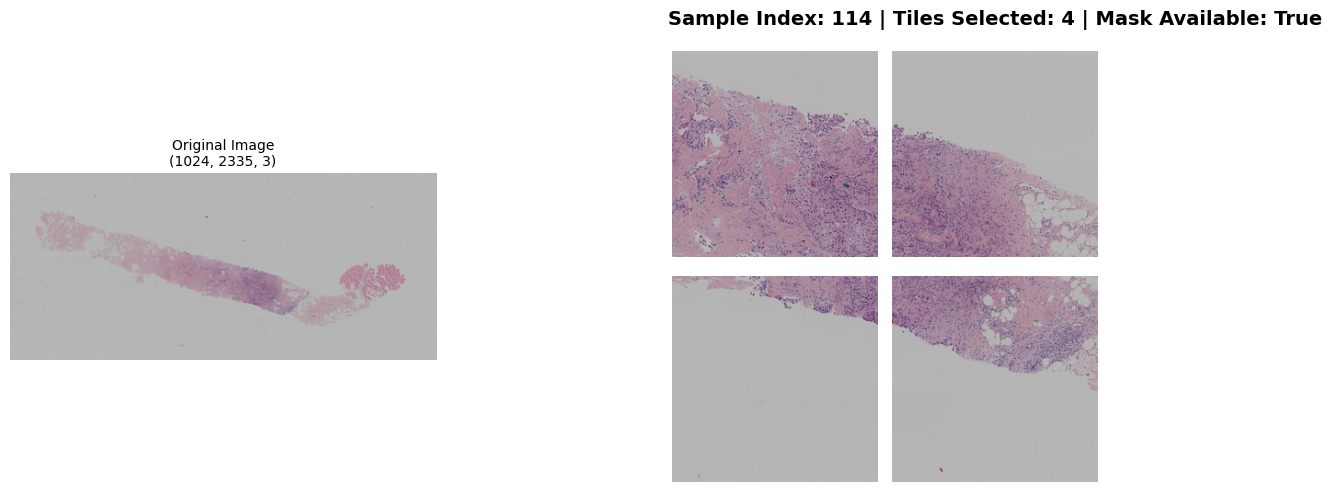

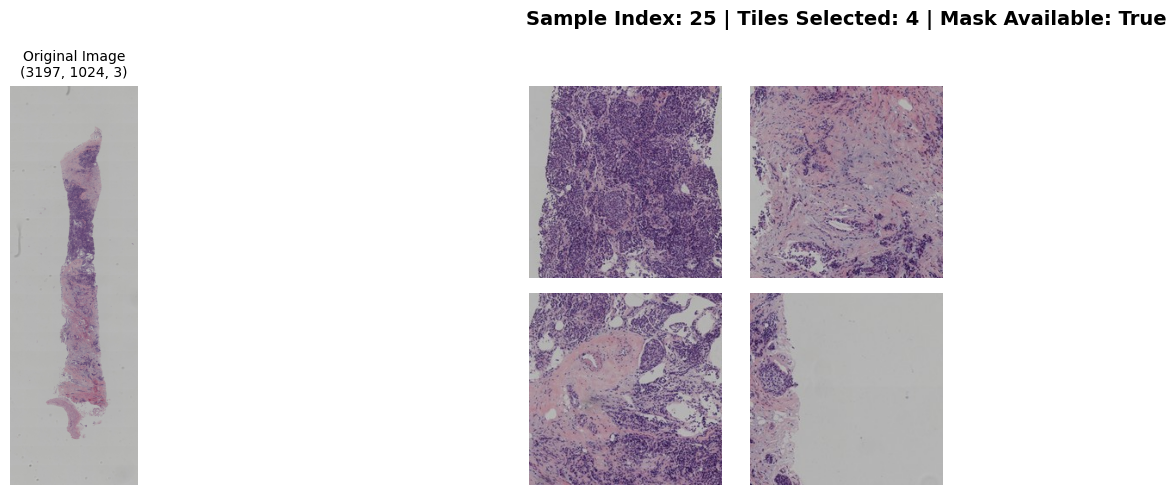

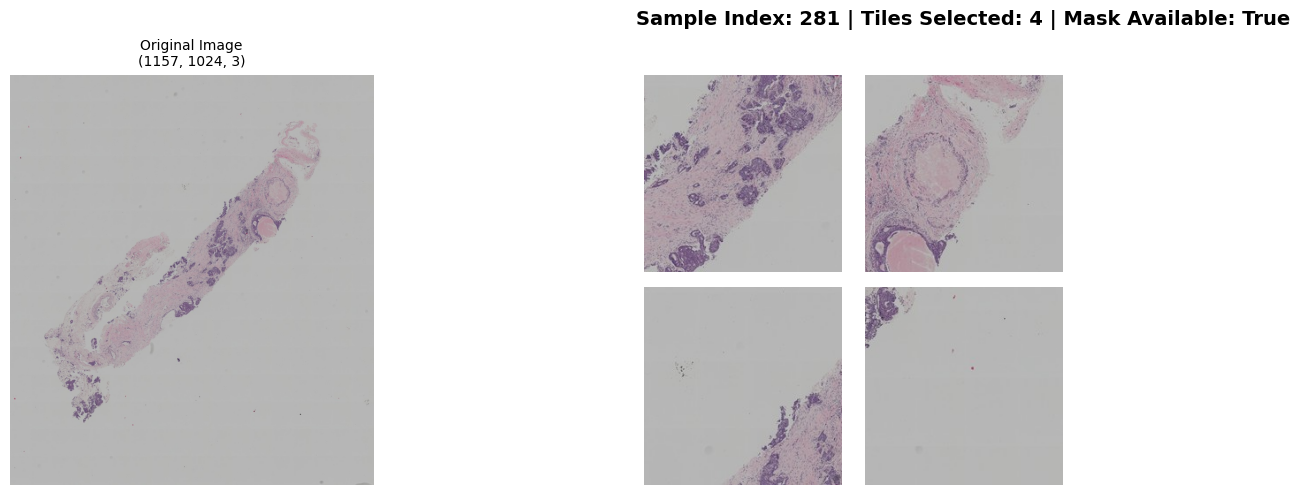

In [10]:
def visualize_smart_tiling(dataset, num_samples=3):
    """
    Picks random images from the dataset and displays the original image
    alongside the N_TILES selected by the SmartTiling algorithm.
    """
    indices = random.sample(range(len(dataset)), num_samples)
    
    for idx in indices:
        # 1. Get Original Image & Mask
        original_img = dataset.images[idx]
        # Check if masks exist and handle the case where they might be None
        if dataset.masks is not None and idx < len(dataset.masks):
            mask = dataset.masks[idx]
        else:
            mask = None
        
        # 2. Get Tiles (Pass both image AND mask)
        # Note: We get raw tiles (uint8) before normalization/tensor conversion
        tiles = dataset.get_best_tiles(original_img, mask)
        
        # 3. Plotting
        fig = plt.figure(figsize=(20, 5))
        
        # Left: Original Image
        ax_main = plt.subplot2grid((2, 9), (0, 0), rowspan=2, colspan=2)
        ax_main.imshow(original_img)
        ax_main.set_title(f"Original Image\n{original_img.shape}", fontsize=10)
        ax_main.axis('off')
        
        # Right: The Selected Tiles
        # We assume N_TILES = 6 (2x3 grid) or adjust accordingly
        grid_size = int(math.ceil(math.sqrt(len(tiles))))
        
        for i, tile in enumerate(tiles):
            # Calculate grid position next to the main image
            row = i // grid_size
            col = i % grid_size
            # Offset col by 2 because the main image takes up slots 0 and 1
            ax_tile = plt.subplot2grid((grid_size, 9), (row, col + 3))
            
            ax_tile.imshow(tile)
            ax_tile.axis('off')
            
            # Optional: Calculate score to see why it was picked
            if mask is not None:
                # Re-calculate mask score for display
                # We need to find the correct coordinates again roughly or just trust the visual
                # For simplicity in visualization, we skip the exact score overlay since we don't have coords here
                color = 'blue' # Mask driven
            else:
                score = dataset.calculate_tissue_score(tile)
                if score == -1.0:
                    color = 'red' # White background / rejected
                else:
                    color = 'green'
                
            for spine in ax_tile.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(2)
                
        plt.suptitle(f"Sample Index: {idx} | Tiles Selected: {len(tiles)} | Mask Available: {mask is not None}", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

# --- EXECUTION ---
# Create a dummy dataset wrapper just for visualization (no transforms needed for viewing)
if 'X_raw' in locals():
    # Create visualization DS with masks
    vis_ds = SmartTiledDataset(
        X_raw, 
        masks=M_raw, # Pass masks here
        labels=None, 
        transform=None, 
        n_tiles=CONFIG.N_TILES, 
        tile_size=CONFIG.TILE_SIZE
    )
    
    print(f"🔍 Visualizing {CONFIG.N_TILES} tiles per image (Prioritizing Masks)...")
    visualize_smart_tiling(vis_ds, num_samples=3)
else:
    print("⚠️ X_raw not found. Make sure you ran the 'Data Loading' cell first.")

##  🛠️ **Model building**

In [11]:
import timm
from transformers import AutoImageProcessor, ViTModel, CLIPVisionModel

import timm
from transformers import AutoImageProcessor, ViTModel, CLIPVisionModel

class Identity(nn.Module):
    def __init__(self): super().__init__()
    def forward(self, x): return x

def build_model(model_name, num_classes, dropout_rate=0.3, feature_extract=False):
    """
    feature_extract=True: Returns model outputting raw embeddings (for XGBoost).
    feature_extract=False: Returns model with classification head (for PyTorch training).
    """
    print(f"🏗️ Building model: {model_name.upper()} | Mode: {'Feature Extraction' if feature_extract else 'Classifier'}")
    
    # --- OPTION A: OWKIN PHIKON ---
    if model_name == "phikon":
        # Load the Foundation Model
        # add_pooling_layer=False gives us access to the raw sequence [CLS] token
        base_model = ViTModel.from_pretrained("owkin/phikon", add_pooling_layer=False)
        
        class PhikonExtractor(nn.Module):
            def __init__(self, base):
                super().__init__()
                self.base = base
                self.dummy_head = nn.Identity() # For compatibility

            def forward(self, x):
                # ViT outputs a tuple/object. We want the last_hidden_state.
                # Shape: [Batch, Tokens, 768]
                out = self.base(x).last_hidden_state
                
                # Take the [CLS] token (index 0) which represents the whole tile
                cls_token = out[:, 0, :] # Shape: [Batch, 768]
                return cls_token

        model = PhikonExtractor(base_model)

    # --- OPTION B: MAHMOOD LAB UNI ---
    elif model_name == "uni":
        try:
            model = timm.create_model("hf_hub:MahmoodLab/UNI", pretrained=True, num_classes=0 if feature_extract else num_classes)
        except:
            # Fallback
            model = timm.create_model("vit_large_patch16_224", pretrained=True, num_classes=0 if feature_extract else num_classes)
            
    # --- OPTION C: EFFICIENTNET / RESNET ---
    elif model_name in ["efficientnet", "resnet50"]:
        if model_name == "efficientnet":
            weights = EfficientNet_V2_S_Weights.DEFAULT
            model = efficientnet_v2_s(weights=weights)
            if feature_extract: model.classifier = Identity() # Remove head
            else: 
                 model.classifier = nn.Linear(model.classifier[1].in_features, num_classes)

        elif model_name == "resnet50":
            weights = ResNet50_Weights.DEFAULT
            model = resnet50(weights=weights)
            if feature_extract: model.fc = Identity() # Remove head
            else: model.fc = nn.Linear(model.fc.in_features, num_classes)

    else:
        raise ValueError(f"Model {model_name} not found.")
        
    return model.to(device)

def set_parameter_requires_grad(model, feature_extracting):
    # Helper to freeze/unfreeze
    if feature_extracting:
        # 1. Freeze EVERYTHING first
        for param in model.parameters():
            param.requires_grad = False
            
        # 2. Unfreeze specific Classification Heads
        if hasattr(model, 'classifier'): # EfficientNet
            for param in model.classifier.parameters(): 
                param.requires_grad = True
                
        elif hasattr(model, 'fc'): # ResNet
            for param in model.fc.parameters(): 
                param.requires_grad = True
                
        elif hasattr(model, 'head'): # Phikon, UNI, PLIP
            for param in model.head.parameters(): 
                param.requires_grad = True
                
        # 3. Unfreeze Norms if present (Phikon)
        if hasattr(model, 'norm'):
            for param in model.norm.parameters():
                param.requires_grad = True

        # 4. PLIP specific: It acts as a wrapper, ensure backbone is frozen
        if hasattr(model, 'backbone'):
             for param in model.backbone.parameters():
                param.requires_grad = False
                
        print("✅ Model frozen. Only head (and norm) are trainable.")
        
    else:
        for param in model.parameters():
            param.requires_grad = True
        print("✅ Model unfrozen. All layers are trainable.")

2025-12-09 09:17:52.841987: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765271873.028444      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765271873.080081      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## 🧠 **Model Tuning** + 💫 **Confusion Matrix**

📦 Preparing Data for Feature Extraction...
🏗️ Building model: PHIKON | Mode: Feature Extraction


config.json:   0%|          | 0.00/492 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of the model checkpoint at owkin/phikon were not used when initializing ViTModel: ['pooler.dense.bias', 'pooler.dense.weight']
- This IS expected if you are initializing ViTModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing ViTModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


⬇️ Extracting features with Mean+Max Aggregation...


[I 2025-12-09 09:18:23,912] A new study created in memory with name: no-name-066f2a24-d6bc-4f02-9d24-d927d3cea070


✅ Extraction Complete. Feature Shape: (579, 1536)
🔭 Starting Optuna with 80 trials...


[I 2025-12-09 09:19:33,264] Trial 0 finished with value: 0.32312867675805956 and parameters: {'n_estimators': 369, 'learning_rate': 0.006768083853819675, 'max_depth': 9, 'subsample': 0.8847340732933768, 'colsample_bytree': 0.88956011338952, 'reg_alpha': 1.0512340064165364e-06, 'reg_lambda': 6.232243879156807, 'min_child_weight': 10}. Best is trial 0 with value: 0.32312867675805956.
[I 2025-12-09 09:21:08,814] Trial 1 finished with value: 0.3565637569764862 and parameters: {'n_estimators': 1339, 'learning_rate': 0.004683898109948663, 'max_depth': 4, 'subsample': 0.7733637940349731, 'colsample_bytree': 0.9485817572574471, 'reg_alpha': 0.3864674283659177, 'reg_lambda': 0.00013873931336363653, 'min_child_weight': 4}. Best is trial 1 with value: 0.3565637569764862.
[I 2025-12-09 09:24:58,702] Trial 2 finished with value: 0.33823912128286576 and parameters: {'n_estimators': 1556, 'learning_rate': 0.0028755785295165627, 'max_depth': 9, 'subsample': 0.5646236917612468, 'colsample_bytree': 0.70


🎉 Best Trial:
  Value: 0.41435331592849345
  Params: {'n_estimators': 1423, 'learning_rate': 0.10905693696996796, 'max_depth': 7, 'subsample': 0.6801254806188426, 'colsample_bytree': 0.8118188837821556, 'reg_alpha': 4.7238589546420956e-08, 'reg_lambda': 8.294280449450552e-06, 'min_child_weight': 4}

📊 Generating Valid Validation Metrics...


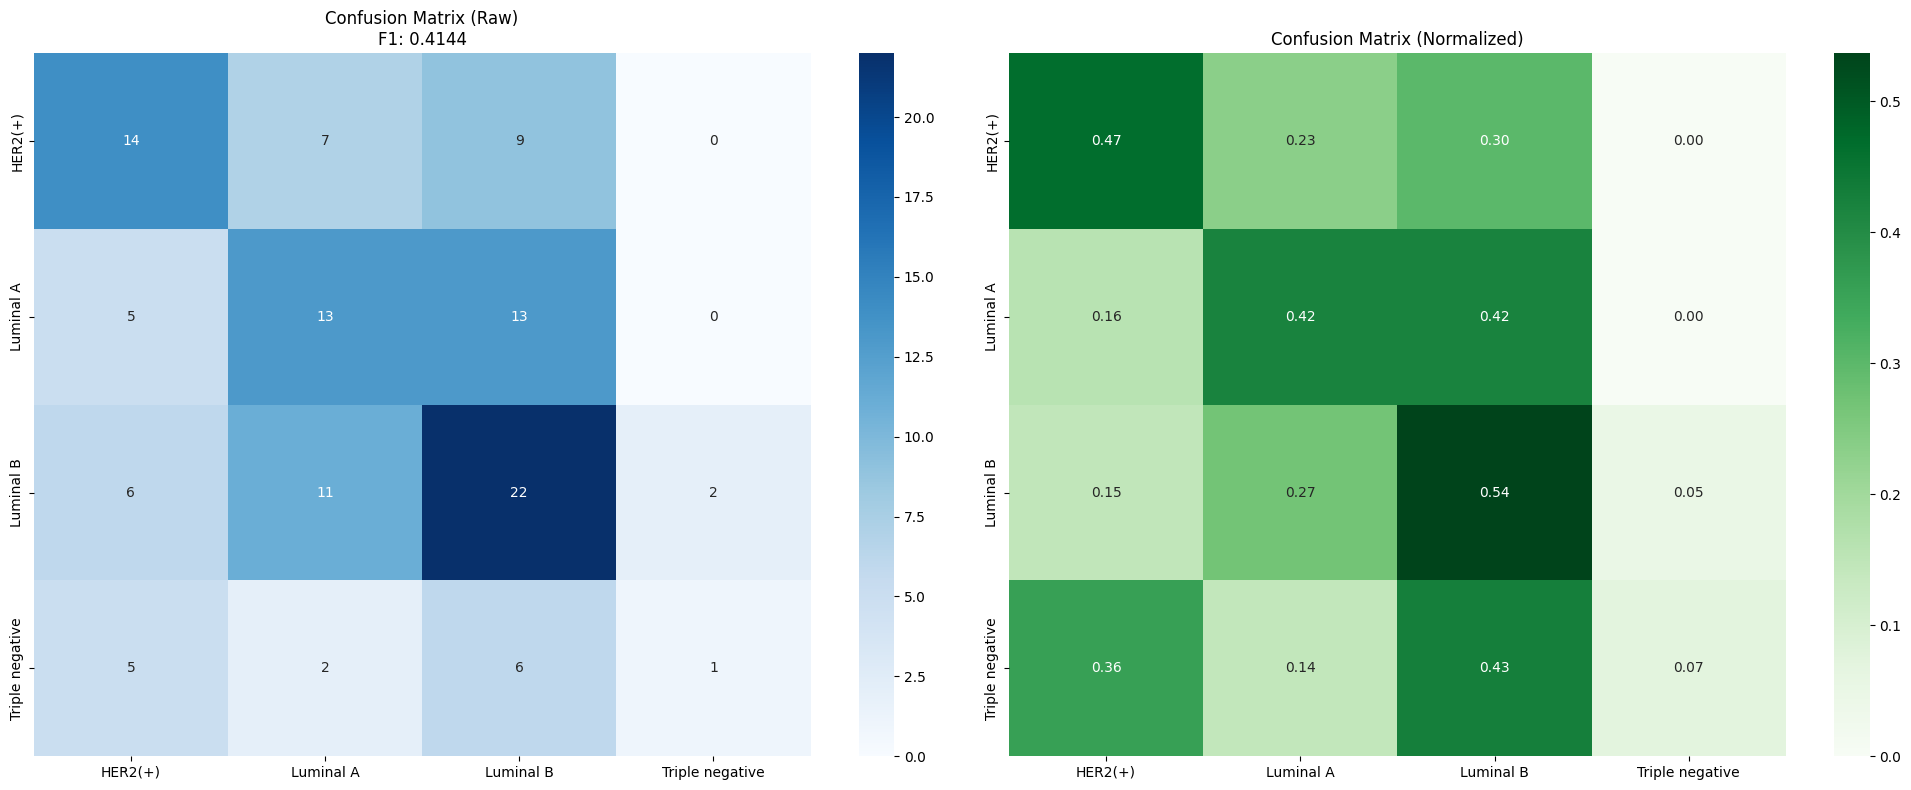


📑 Classification Report:
                 precision    recall  f1-score   support

        HER2(+)       0.47      0.47      0.47        30
      Luminal A       0.39      0.42      0.41        31
      Luminal B       0.44      0.54      0.48        41
Triple negative       0.33      0.07      0.12        14

       accuracy                           0.43       116
      macro avg       0.41      0.37      0.37       116
   weighted avg       0.42      0.43      0.41       116


🏋️ Training Final Model on ALL data (Feature Shape: (579, 1536))
✅ Final Model Saved: best_xgboost_optuna.json


In [12]:
import xgboost as xgb
import optuna
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import seaborn as sns

# --- UPDATED HELPER: ROBUST FEATURE EXTRACTION ---
def extract_features(model, loader, device):
    """
    Runs images through the model and aggregates tiles using Mean+Max pooling.
    """
    model.eval()
    features = []
    labels = []
    
    print("⬇️ Extracting features with Mean+Max Aggregation...")
    
    with torch.no_grad():
        for batch in loader:
            # 1. Unpack Batch
            if isinstance(batch, (list, tuple)) and len(batch) == 2:
                imgs, lbls = batch
                labels.append(lbls.numpy())
            else:
                imgs = batch
                # No labels (Inference mode)

            imgs = imgs.to(device)
            
            # 2. Reshape for the Backbone: [Batch, Tiles, C, H, W] -> [Batch*Tiles, C, H, W]
            bs, n_tiles, c, h, w = imgs.size()
            imgs = imgs.view(-1, c, h, w)
            
            # 3. Forward Pass (Mixed Precision for speed)
            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                # Phikon Extractor returns [Batch*Tiles, 768]
                embeddings = model(imgs) 
            
            # 4. Restore Batch Dimension: [Batch, Tiles, 768]
            embed_dim = embeddings.shape[1]
            embeddings = embeddings.view(bs, n_tiles, embed_dim)
            
            # 5. ✨ SMART AGGREGATION (Mean + Max) ✨
            # Mean: Captures the average texture
            mean_emb = torch.mean(embeddings, dim=1)
            # Max: Captures the strongest feature activation (the "tumor" signal)
            max_emb, _ = torch.max(embeddings, dim=1)
            
            # Concatenate: Result dim becomes 768 + 768 = 1536
            slide_embedding = torch.cat([mean_emb, max_emb], dim=1)
            
            features.append(slide_embedding.cpu().numpy())
            
    # Final Stack
    X_emb = np.vstack(features)
    y_emb = np.concatenate(labels) if labels else None
    
    return X_emb, y_emb

# --- MAIN EXECUTION ---

# 1. Prepare Data Loaders (Validation Transform for consistency)
print("📦 Preparing Data for Feature Extraction...")
_, val_tf = get_transforms()

# Pass M_raw (Masks)
full_ds = SmartTiledDataset(X_raw, masks=M_raw, labels=y_encoded, transform=val_tf, n_tiles=CONFIG.N_TILES)
full_loader = DataLoader(full_ds, batch_size=CONFIG.BATCH_SIZE, shuffle=False, num_workers=2)

# 2. Load Backbone & Extract Features
# Check if we need to reload backbone or if it exists from previous cell
if 'backbone' not in locals():
    backbone = build_model(CONFIG.MODEL_NAME, num_classes=0, feature_extract=True)

X_emb, y_emb = extract_features(backbone, full_loader, device)

print(f"✅ Extraction Complete. Feature Shape: {X_emb.shape}")

# 3. Split Data for Optuna (Train/Val)
X_train, X_val, y_train, y_val = train_test_split(
    X_emb, y_emb, test_size=CONFIG.TEST_SIZE, random_state=SEED, stratify=y_emb
)

# 4. Define Optuna Objective
def objective(trial):
    params = {
        'objective': 'multi:softmax',
        'num_class': len(le.classes_),
        'tree_method': 'hist', # Use 'gpu_hist' if GPU is available
        'eval_metric': 'mlogloss',
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
    }
    
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], early_stopping_rounds=50, verbose=False)
    preds = model.predict(X_val)
    return f1_score(y_val, preds, average='weighted')

# 5. Run Optimization
print(f"🔭 Starting Optuna with {CONFIG.N_TRIALS} trials...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=CONFIG.N_TRIALS)

print("\n🎉 Best Trial:")
print(f"  Value: {study.best_value}")
print(f"  Params: {study.best_params}")

# --- 📊 GENERATE METRICS (BEFORE RETRAINING) ---
print("\n📊 Generating Valid Validation Metrics...")
best_params = study.best_params
best_params['objective'] = 'multi:softmax'
best_params['num_class'] = len(le.classes_)
best_params['tree_method'] = 'hist'

# Train a temp model on X_train only to evaluate on X_val cleanly
val_model = xgb.XGBClassifier(**best_params)
val_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], early_stopping_rounds=50, verbose=False)
val_preds = val_model.predict(X_val)

# Confusion Matrix
class_names = le.classes_
cm = confusion_matrix(y_val, val_preds)
cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title(f'Confusion Matrix (Raw)\nF1: {f1_score(y_val, val_preds, average="weighted"):.4f}')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)')
plt.tight_layout()
plt.show()

print("\n📑 Classification Report:")
print(classification_report(y_val, val_preds, target_names=class_names))

# 6. Train Final Model on ALL Data (Train + Val)
print("\n🏋️ Training Final Model on ALL data (Feature Shape: {})".format(X_emb.shape))
final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_emb, y_emb) 

# Save
final_model.save_model("best_xgboost_optuna.json")
print("✅ Final Model Saved: best_xgboost_optuna.json")

## 🕹️ **Use the Model - Make Inference**

In [13]:
print("\n🤖 Starting Inference with TTA (3x: Original, H-Flip, V-Flip)...")

# 1. Load Test Data
X_test_raw, M_test_raw, test_filenames = load_images(CONFIG.TEST_DIR, file_list=None)

if len(X_test_raw) > 0:
    # --- DEFINE TTA TRANSFORMS ---
    # We define 3 separate transforms to force specific augmentations
    
    # 1. Standard (No Flip)
    base_tf = v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # 2. Horizontal Flip (p=1.0 forces the flip)
    hflip_tf = v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.RandomHorizontalFlip(p=1.0),
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # 3. Vertical Flip (p=1.0 forces the flip)
    vflip_tf = v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.RandomVerticalFlip(p=1.0),
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    tta_transforms = {'Original': base_tf, 'HFlip': hflip_tf, 'VFlip': vflip_tf}

    # 2. ENSURE BACKBONE EXISTS
    if 'backbone' not in locals():
        print("🔄 Backbone not found. Reloading...")
        backbone = build_model(CONFIG.MODEL_NAME, num_classes=0, feature_extract=True)

    # 3. LOAD XGBOOST MODEL
    xgb_model = xgb.XGBClassifier()
    xgb_model.load_model("best_xgboost_optuna.json")

    # 4. TTA LOOP
    final_probs = 0
    
    for name, tf in tta_transforms.items():
        print(f"  ⚡ Processing TTA Round: {name}...")
        
        # 🆕 Pass M_test_raw
        test_ds = SmartTiledDataset(
            X_test_raw, 
            masks=M_test_raw, 
            labels=None, 
            transform=tf, 
            n_tiles=CONFIG.N_TILES
        )
        test_loader = DataLoader(test_ds, batch_size=CONFIG.BATCH_SIZE, shuffle=False, num_workers=2)
        
        # Extract Features
        X_test_emb, _ = extract_features(backbone, test_loader, device)
        
        # XGBoost Prediction
        probs = xgb_model.predict_proba(X_test_emb)
        final_probs += probs

    # 5. AVERAGE & DECODE (This must be OUTSIDE the loop)
    final_probs /= len(tta_transforms) 
    final_preds = np.argmax(final_probs, axis=1)
    predicted_labels = le.inverse_transform(final_preds)
    
    # 6. SAVE
    submission = pd.DataFrame({
        'sample_index': test_filenames,
        'label': predicted_labels
    })
    submission.to_csv("submission_optuna_tta.csv", index=False)
    print("🏆 TTA Submission Saved: submission_optuna_tta.csv")

else:
    print("⚠️ No test data found.")


🤖 Starting Inference with TTA (3x: Original, H-Flip, V-Flip)...
📂 Loading 477 raw images and masks from /kaggle/input/grumpy-doctogres-no-shrek-no-boggers/an2dl2526c2v2/test_data...
  ⚡ Processing TTA Round: Original...
⬇️ Extracting features with Mean+Max Aggregation...
  ⚡ Processing TTA Round: HFlip...
⬇️ Extracting features with Mean+Max Aggregation...
  ⚡ Processing TTA Round: VFlip...
⬇️ Extracting features with Mean+Max Aggregation...
🏆 TTA Submission Saved: submission_optuna_tta.csv
